E-4: Rifaccia l'E-1, questa volta in PyTorch, lasciando che sia la libreria a calcolare il gradiente per lei con loss.backward() e ad aggiornare i
parametri con torch.optim.SGD. Stampi param.grad dopo la chiamata e verifichi che assomigli al gradiente calcolato a mano in E-1: è la
stessa identica cosa, solo automatizzata.

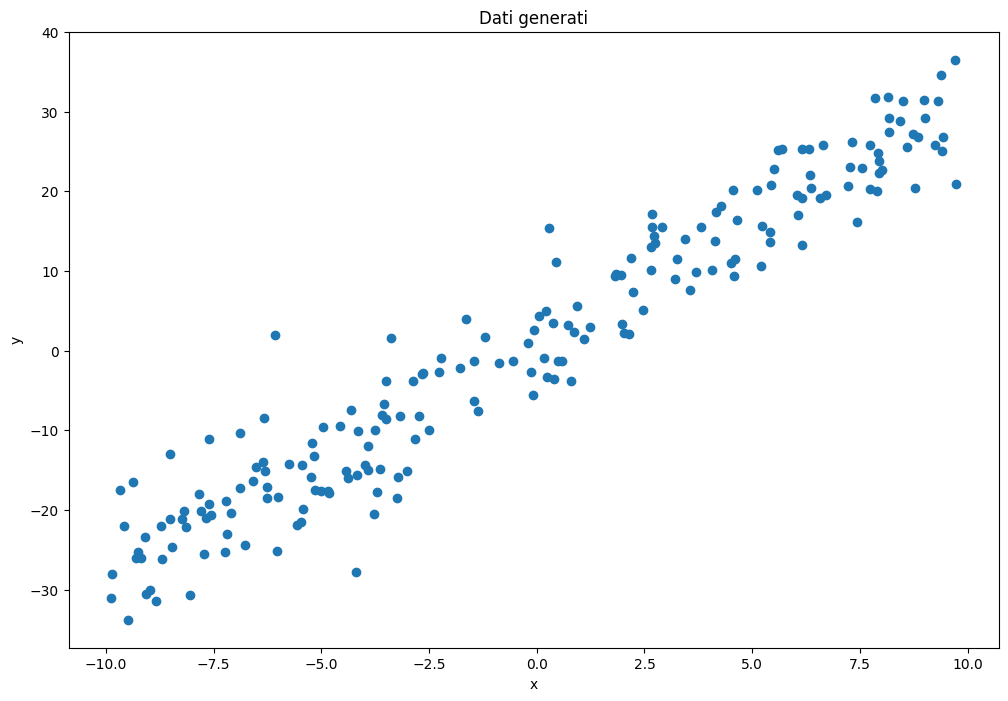

Iterazione 1
Gradiente m: -206.07025146484375
Gradiente q: -0.754890501499176
Iterazione 2
Gradiente m: -63.00965118408203
Gradiente q: -2.0581281185150146
Iterazione 3
Gradiente m: -19.278018951416016
Gradiente q: -2.4200711250305176
Iterazione 4
Gradiente m: -5.909622669219971
Gradiente q: -2.4950013160705566
Iterazione 5
Gradiente m: -1.8227894306182861
Gradiente q: -2.482908248901367
Iterazione 6
Gradiente m: -0.5731971263885498
Gradiente q: -2.444911003112793
Iterazione 7
Gradiente m: -0.19088804721832275
Gradiente q: -2.3996798992156982
Iterazione 8
Gradiente m: -0.07372239232063293
Gradiente q: -2.3529064655303955
Iterazione 9
Gradiente m: -0.037593990564346313
Gradiente q: -2.3063199520111084
Iterazione 10
Gradiente m: -0.02624577283859253
Gradiente q: -2.260435104370117
Iterazione 11
Gradiente m: -0.022482097148895264
Gradiente q: -2.215393304824829
Iterazione 12
Gradiente m: -0.021048367023468018
Gradiente q: -2.171229124069214
Iterazione 13
Gradiente m: -0.020321011543273926

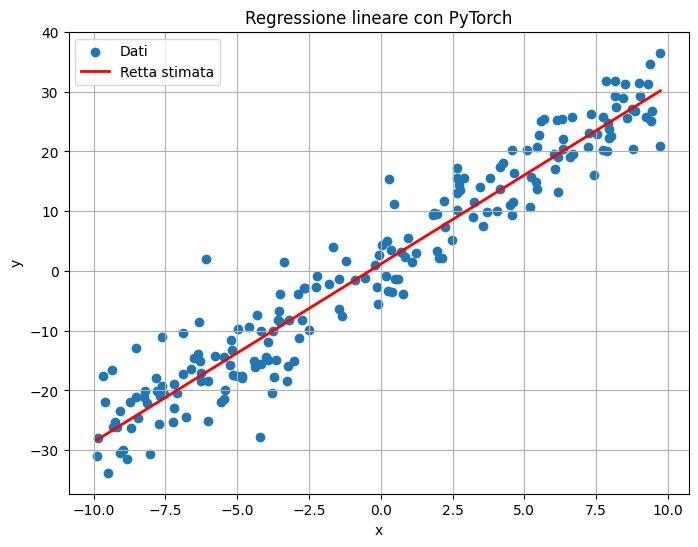

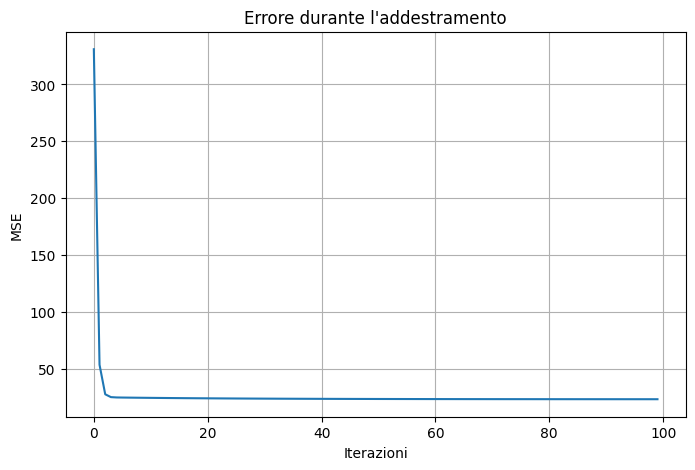

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

#Generazione dei dati
np.random.seed(42)
torch.manual_seed(42)

#Definisco il numero di punti da generare
N = 200

x = np.random.uniform(-10, 10, N)
rumore = np.random.normal(0, 5, N)

y = 3 * x + 1 + rumore

#Visualizzazione dei dati
plt.figure(figsize=(12,8))
plt.scatter(x,y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Dati generati')

plt.show()

# Conversione in tensori
x = torch.tensor(x, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

#Creo i parametri per il calcolo del gradiente
m = torch.tensor(0.0, requires_grad=True)
q = torch.tensor(0.0, requires_grad=True)

#Ottimizzatore
optimizer = torch.optim.SGD([m, q], lr=0.01)

#Definisco il numero di iterazioni
iterazioni = 100
errori = []

#Calcolo il gradiente
for i in range(iterazioni):

    #Azzera i gradienti
    optimizer.zero_grad()

    #Predizione della y
    y_pred = m * x + q

    #MSE
    MSE = torch.mean((y_pred - y) ** 2)

    #Calcolo automatico dei gradienti
    MSE.backward()

    #Stampa dei gradienti
    print(f"Iterazione {i+1}")
    print("Gradiente m:", m.grad.item())
    print("Gradiente q:", q.grad.item())

    #Aggiornamento parametri
    optimizer.step()

    errori.append(MSE.item())

#Stampa dei risultati
print("\nParametri finali")
print("m =", m.item())
print("q =", q.item())

#Grafico dati e retta
plt.figure(figsize=(8,6))
plt.scatter(x.numpy(), y.numpy(), label="Dati")

ordine = torch.argsort(x)

plt.plot(
    x[ordine].detach().numpy(),
    (m * x + q)[ordine].detach().numpy(),
    color="red",
    linewidth=2,
    label="Retta stimata"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Regressione lineare con PyTorch")
plt.legend()
plt.grid(True)
plt.show()

#Grafico degli errori
plt.figure(figsize=(8,5))
plt.plot(errori)
plt.xlabel("Iterazioni")
plt.ylabel("MSE")
plt.title("Errore durante l'addestramento")
plt.grid(True)
plt.show()

